<a href="https://colab.research.google.com/github/NavdeeepSinghh/Deep_Learning-LAB/blob/main/Lab_7_From_Numbers_to_Vision_Building%2C_Breaking%2C_Comparing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Imports + Dataset Generation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Dataset size
N = 3000

# Generate data
x1 = np.random.uniform(-2, 2, N)
x2 = np.random.uniform(-2, 2, N)

X = np.column_stack((x1, x2))

y = ((x1**2 + x2**2) > 1.5).astype(int).reshape(-1,1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3000, 2)
y shape: (3000, 1)


#Train / Val / Test Split

In [ ]:
# Shuffle
indices = np.random.permutation(N)
X = X[indices]
y = y[indices]

train_end = int(0.7 * N)
val_end = int(0.85 * N)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (2100, 2)
Val: (450, 2)
Test: (450, 2)


#Activation Functions

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

#nitialize Deep Network

In [ ]:
def initialize(layer_dims):
    params = {}
    L = len(layer_dims)

    for l in range(1, L):
        params["W"+str(l)] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2/layer_dims[l-1])
        params["b"+str(l)] = np.zeros((layer_dims[l],1))

    return params

#Forward Pass

In [ ]:
def forward(X, params, activation="relu"):
    A = X.T
    cache = {}
    L = len(params)//2

    for l in range(1, L):
        Z = params["W"+str(l)] @ A + params["b"+str(l)]
        cache["Z"+str(l)] = Z

        if activation == "relu":
            A = relu(Z)
        else:
            A = sigmoid(Z)

        cache["A"+str(l)] = A

    # Output layer
    ZL = params["W"+str(L)] @ A + params["b"+str(L)]
    AL = sigmoid(ZL)

    cache["Z"+str(L)] = ZL
    cache["A"+str(L)] = AL

    return AL, cache

#Loss (BCE with Clipping)

In [ ]:
def compute_loss(AL, y):
    m = y.shape[0]
    y = y.T

    AL = np.clip(AL, 1e-8, 1-1e-8)

    loss = -(1/m) * np.sum(y*np.log(AL) + (1-y)*np.log(1-AL))
    return loss

#Backpropagation

In [ ]:
def backward(X, y, params, cache, activation="relu"):
    grads = {}
    m = X.shape[0]
    L = len(params)//2

    y = y.T
    AL = cache["A"+str(L)]

    dZ = AL - y

    for l in reversed(range(1, L+1)):
        A_prev = X.T if l == 1 else cache["A"+str(l-1)]

        grads["dW"+str(l)] = (1/m) * dZ @ A_prev.T
        grads["db"+str(l)] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

        if l > 1:
            dA_prev = params["W"+str(l)].T @ dZ
            Z_prev = cache["Z"+str(l-1)]

            if activation == "relu":
                dZ = dA_prev * relu_deriv(Z_prev)
            else:
                dZ = dA_prev * sigmoid_deriv(Z_prev)

    return grads

#Optimizers

In [ ]:
def update_sgd(params, grads, lr):
    L = len(params)//2
    for l in range(1, L+1):
        params["W"+str(l)] -= lr * grads["dW"+str(l)]
        params["b"+str(l)] -= lr * grads["db"+str(l)]
    return params

In [ ]:
def update_momentum(params, grads, velocity, lr, beta=0.9):
    L = len(params)//2

    for l in range(1, L+1):
        velocity["dW"+str(l)] = beta*velocity["dW"+str(l)] + lr*grads["dW"+str(l)]
        velocity["db"+str(l)] = beta*velocity["db"+str(l)] + lr*grads["db"+str(l)]

        params["W"+str(l)] -= velocity["dW"+str(l)]
        params["b"+str(l)] -= velocity["db"+str(l)]

    return params, velocity

#Accuracy + Gradient Norm

In [ ]:
def accuracy(AL, y):
    preds = (AL.T >= 0.5).astype(int)
    return np.mean(preds == y)

def grad_norm(grads):
    total = 0
    for key in grads:
        total += np.sum(grads[key]**2)
    return np.sqrt(total)

#Training Function

In [ ]:
def train_model(layer_dims, activation="relu", optimizer="sgd", epochs=200, lr=0.01):

    params = initialize(layer_dims)
    velocity = {key: np.zeros_like(params[key]) for key in params}

    history = {"train_loss":[], "val_loss":[],
               "train_acc":[], "val_acc":[],
               "grad_norm":[]}

    for epoch in range(epochs):

        AL, cache = forward(X_train, params, activation)
        loss = compute_loss(AL, y_train)
        grads = backward(X_train, y_train, params, cache, activation)

        if optimizer == "sgd":
            params = update_sgd(params, grads, lr)
        else:
            params, velocity = update_momentum(params, grads, velocity, lr)

        # Validation
        AL_val, _ = forward(X_val, params, activation)

        history["train_loss"].append(loss)
        history["val_loss"].append(compute_loss(AL_val, y_val))
        history["train_acc"].append(accuracy(AL, y_train))
        history["val_acc"].append(accuracy(AL_val, y_val))
        history["grad_norm"].append(grad_norm(grads))

        if epoch % 20 == 0:
            print("Epoch", epoch, "Loss", loss)

    return params, history

#Example

In [ ]:
layer_dims = [2, 8, 1]

params, history = train_model(layer_dims,
                              activation="relu",
                              optimizer="sgd",
                              epochs=300,
                              lr=0.05)

Epoch 0 Loss 1.4623864251712386
Epoch 20 Loss 0.6638272296760498
Epoch 40 Loss 0.5803083693596092
Epoch 60 Loss 0.5617556524526776
Epoch 80 Loss 0.5516473863622913
Epoch 100 Loss 0.5437101085723394
Epoch 120 Loss 0.5366596103461825
Epoch 140 Loss 0.529963444891907
Epoch 160 Loss 0.5234022512439963
Epoch 180 Loss 0.5168683546270614
Epoch 200 Loss 0.5102874063640581
Epoch 220 Loss 0.5036113314390583
Epoch 240 Loss 0.4967836940114033
Epoch 260 Loss 0.4898723294905018
Epoch 280 Loss 0.4828118924053617


#Plot

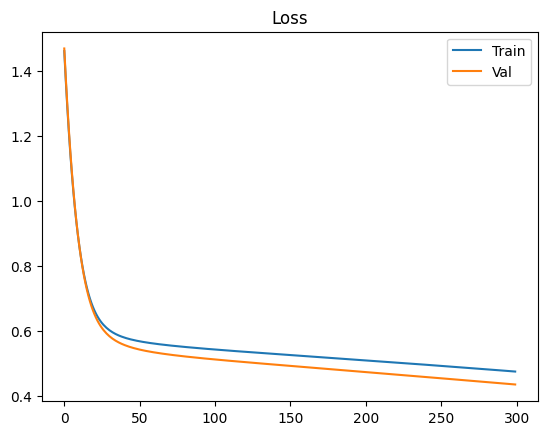

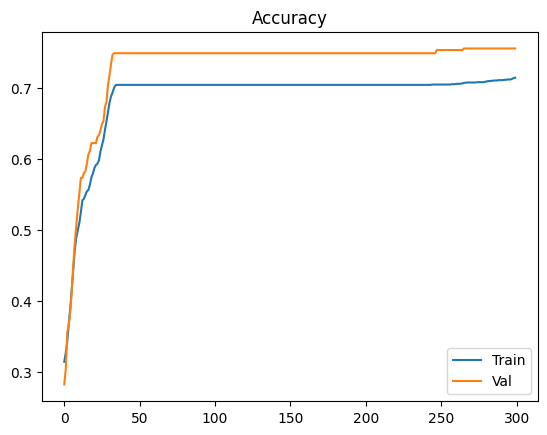

In [ ]:
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.show()

plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Val")
plt.title("Accuracy")
plt.legend()
plt.show()